# Exploratory Data Analysis (EDA)

## Objective

This notebook aims to explore the cleaned e-commerce dataset to identify business patterns, trends, and insights that can support decision-making.

The analysis focuses on:
- Sales performance
- Customer behavior
- Product performance
- Seller performance
- Delivery performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


processed_path = "../Data/processed/"
customers = pd.read_csv(processed_path + "customers.csv")
orders = pd.read_csv(
    processed_path + "orders.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items = pd.read_csv(
    processed_path + "order_items.csv",
    parse_dates=["shipping_limit_date"]
)

payments = pd.read_csv(processed_path + "payments.csv")
reviews = pd.read_csv(processed_path + "reviews.csv")   
products = pd.read_csv(processed_path + "products.csv")
sellers = pd.read_csv(processed_path + "sellers.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}


## 3.1 Sales Performance Analysis

### Business Question

How has the sales performance changed over time?

This analysis aims to understand the overall sales trend and identify whether the business experienced growth, decline, or seasonal patterns throughout the observed period.

In [2]:
overview = []
for dataset_name, dataset in datasets.items():
    overview.append({
        "dataset": dataset_name,
        "rows": dataset.shape[0],
        "columns": dataset.shape[1],
    })

overview

[{'dataset': 'customers', 'rows': 99441, 'columns': 5},
 {'dataset': 'orders', 'rows': 99441, 'columns': 8},
 {'dataset': 'order_items', 'rows': 112650, 'columns': 7},
 {'dataset': 'payments', 'rows': 103886, 'columns': 5},
 {'dataset': 'reviews', 'rows': 99224, 'columns': 7},
 {'dataset': 'products', 'rows': 32951, 'columns': 9},
 {'dataset': 'sellers', 'rows': 3095, 'columns': 4}]

## 3.1 Sales Performance Analysis

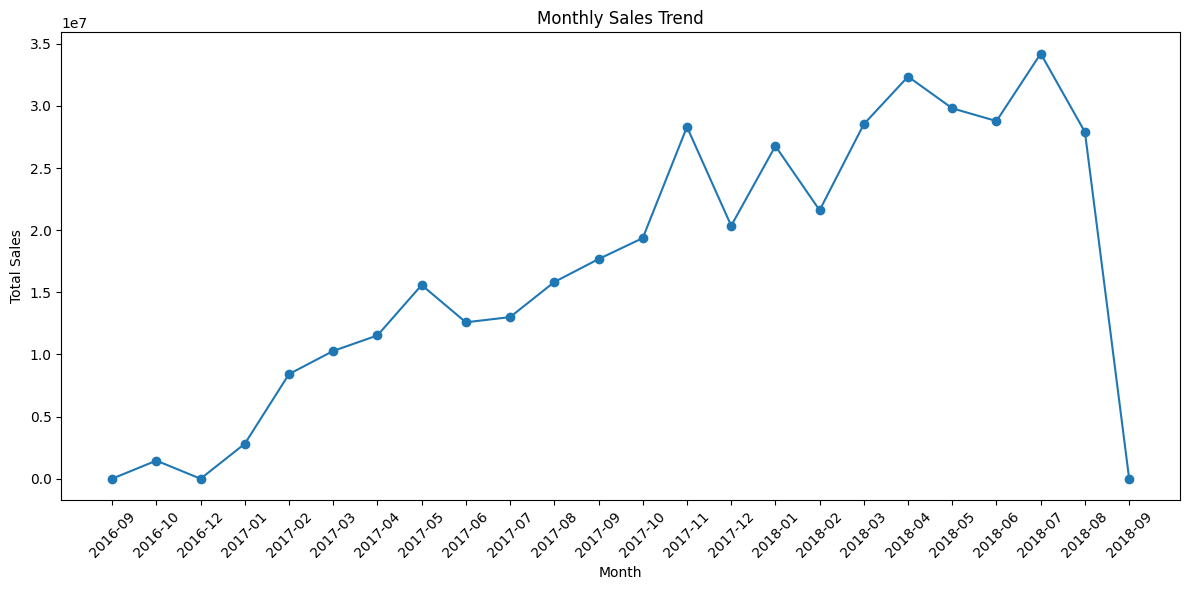

In [3]:
sales = pd.merge(
    orders,
    order_items,
    on="order_id",
    how="inner"
)

sales["total_sales"] = sales["price"] * sales["freight_value"]


#Sales by Month
sales["order_month"] = sales["order_purchase_timestamp"].dt.to_period("M") 
# Monthly Sales
monthly_sales = (sales.groupby("order_month")["total_sales"].sum().reset_index())
monthly_sales

# Visualization Sales by Month
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales["order_month"].astype(str),
        monthly_sales["total_sales"], 
        marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### 3.1 1. Monthly Sales Trend

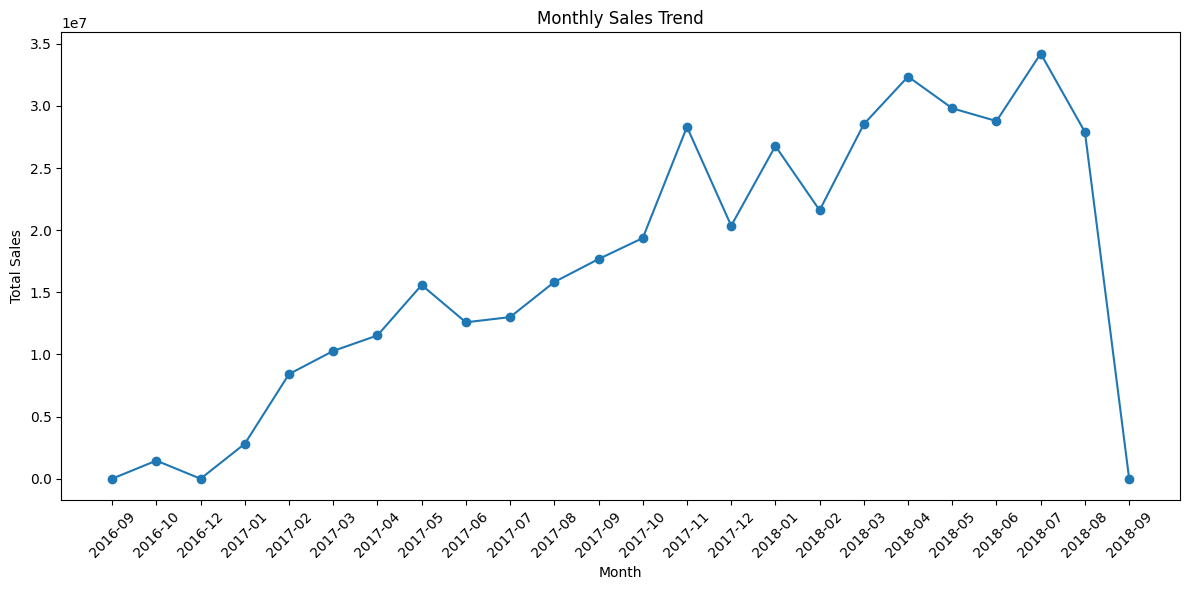

In [4]:
sales["total_sales"] = sales["price"] * sales["freight_value"]

#Sales by Month
sales["order_month"] = sales["order_purchase_timestamp"].dt.to_period("M") 
# Monthly Sales
monthly_sales = (sales.groupby("order_month")["total_sales"].sum().reset_index())
monthly_sales

# Visualization Sales by Month
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales["order_month"].astype(str),
        monthly_sales["total_sales"], 
        marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()

### 3.1.2 Monthly Revenue

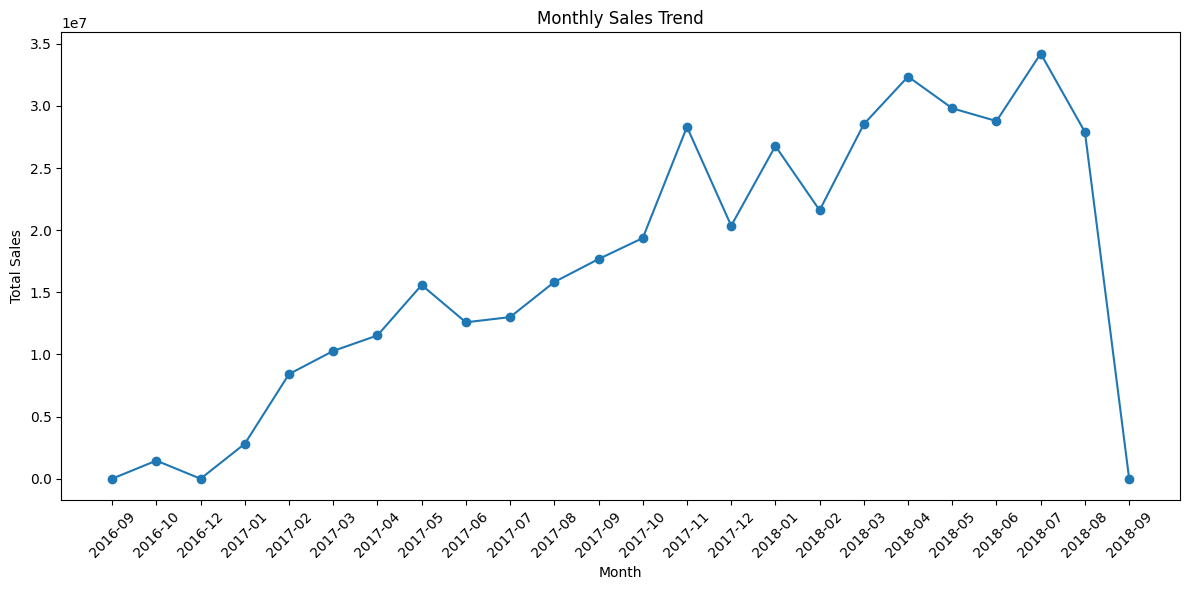

In [5]:
monthly_sales = (
    sales.groupby("order_month", as_index=False)
    .agg(
        total_sales=("total_sales", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_sales

#Visualtion Month Revenue
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_month"].astype(str),
    monthly_sales["total_sales"],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.2 Customer Behavior Analysis
Business Question : Which customer segments contribute the most to the business?

In [6]:
customer_orders = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)

customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [7]:
total_customers = customer_orders["customer_unique_id"].nunique()
print (f"Total Unique Customers: {total_customers}")

Total Unique Customers: 96096


In [12]:
customers_by_state = (
    customer_orders
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="total_customers")

)

customers_by_state.head(10)

,customer_state,total_customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


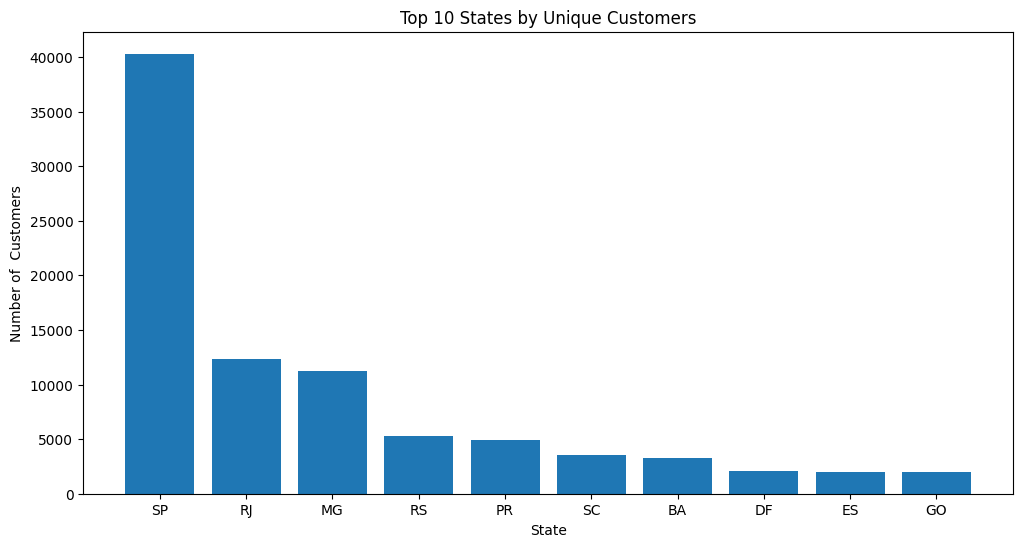

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    customers_by_state["customer_state"][:10],
    customers_by_state["total_customers"][:10]
)

plt.title("Top 10 States by Unique Customers")
plt.xlabel("State")
plt.ylabel("Number of  Customers")

plt.show()

In [14]:
customers_by_state["customer_percentage"] = (
    customers_by_state["total_customers"]
    / customers_by_state["total_customers"].sum()
) * 100

customers_by_state.head(10)

,customer_state,total_customers,customer_percentage
0,SP,40302,41.921861
1,RJ,12384,12.881751
2,MG,11259,11.711534
3,RS,5277,5.489099
4,PR,4882,5.078223
5,SC,3534,3.676042
6,BA,3277,3.408713
7,DF,2075,2.158401
8,ES,1964,2.042939
9,GO,1952,2.030457


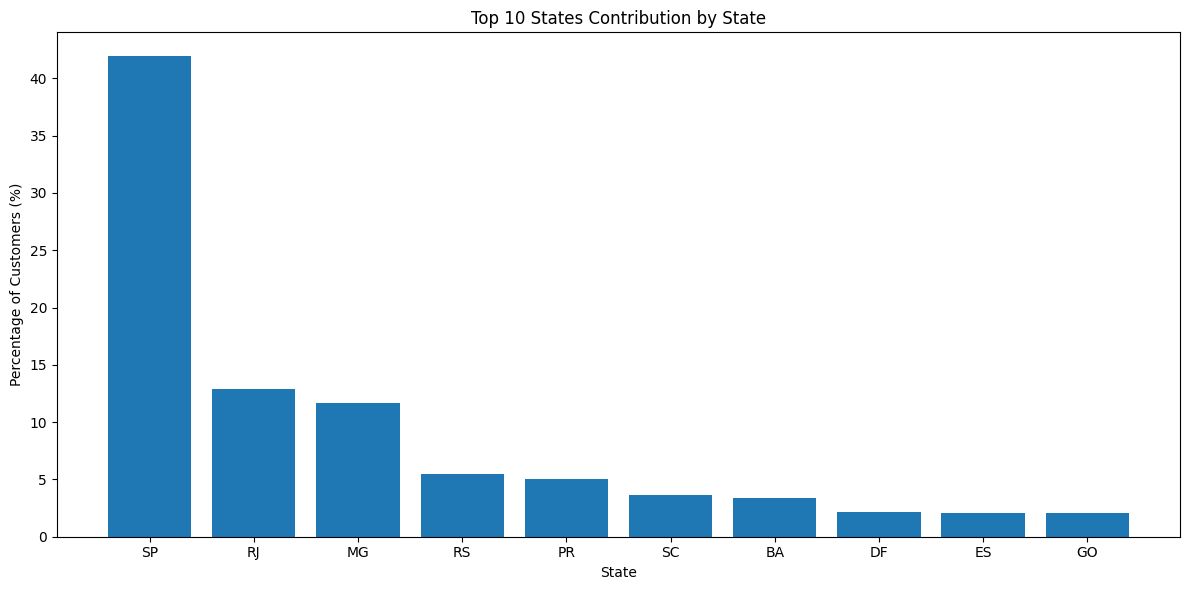

In [15]:
plt.figure(figsize=(12, 6))

plt.bar(
    customers_by_state["customer_state"][:10],
    customers_by_state["customer_percentage"][:10] 
)

plt.title("Top 10 States Contribution by State")
plt.xlabel ("State")
plt.ylabel ("Percentage of Customers (%)")

plt.tight_layout()
plt.show()

## 3.3 Product Perfomance Analysis
Business Question

Which product categories generate the highest sales revenue?

In [ ]:
import pandas as pd

translations = pd.read_csv("../Data/raw/product_category_name_translation.csv", sep=";")
translations.head()

In [ ]:
product_sales = (
    sales
    .merge(products, on="product_id", how="left")
    .merge(translations, on="product_category_name", how="left")
)

product_sales.head()

NameError: name 'translations' is not defined

In [ ]:
category_sales = (
    
)